Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Create a dataset

In [2]:
X, y = make_regression(
    n_samples=200,
    n_features=10,
    n_informative=5,
    noise=20,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Train models

In [3]:
models = {
    "No Regularization": LinearRegression(),
    "L2 (Ridge)": Ridge(alpha=1.0),
    "L1 (Lasso)": Lasso(alpha=0.1),
    "Elastic Net": ElasticNet(alpha=0.1, l1_ratio=0.5)
}

coefficients = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    coefficients[name] = model.coef_


Compare Coefficients

In [4]:
coef_df = pd.DataFrame(coefficients)
coef_df.index = [f"Feature {i}" for i in range(X.shape[1])]

print(coef_df)

           No Regularization  L2 (Ridge)  L1 (Lasso)  Elastic Net
Feature 0           0.958037    1.013209    0.859571     1.260737
Feature 1          -2.156620   -2.208973   -2.050963    -2.437172
Feature 2           6.964821    6.819641    6.833494     5.959776
Feature 3          77.787095   77.205524   77.718954    73.866613
Feature 4           1.846768    1.830820    1.724655     1.680448
Feature 5          36.449345   36.245844   36.387826    35.039664
Feature 6           9.206564    9.138386    9.111257     8.711947
Feature 7          38.174200   37.905975   38.035289    36.310031
Feature 8           1.790018    1.831521    1.704942     2.007872
Feature 9          -1.263533   -1.299387   -1.162235    -1.443476


Visual Comparison

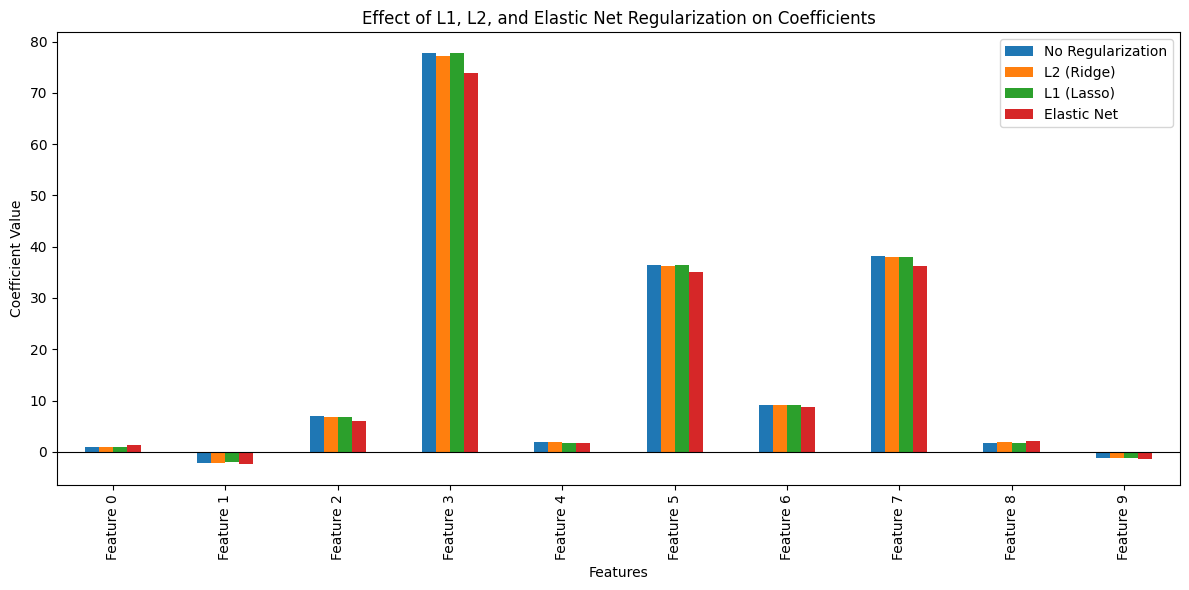

In [5]:
coef_df.plot(kind="bar", figsize=(12,6))
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Effect of L1, L2, and Elastic Net Regularization on Coefficients")
plt.ylabel("Coefficient Value")
plt.xlabel("Features")
plt.legend()
plt.tight_layout()
plt.show()